# 01 - Preeclampsia Risk Score Model Training (LightGBM Regression)

## Project: Agentic AI for Pregnancy Monitoring
### Task: Predict **Preeclampsia Risk Score** (0–1) using live + periodic patient data  
✅ Model Type: **Regression (LightGBM)**  
✅ Output: `preeclampsia_risk_score`  
✅ Tiering: Rule-based thresholds (Low/Medium/High)

---

### Key Notes
- We use **patient-wise split** (`patient_id`) to prevent data leakage.
- We use **feature engineering** (Pulse Pressure, MAP, Symptom Sum).
- We use **missing indicators** for periodic/manual fields (weight, proteinuria, HbA1c).
- We use early stopping to avoid overfitting.
- Target column: `preeclampsia_risk_score_label`


In [18]:
# If LightGBM is not installed, uncomment below:
!pip install lightgbm

import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import joblib
import json
import os

import lightgbm as lgb

np.random.seed(42)


Defaulting to user installation because normal site-packages is not writeable


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1) Load Dataset

We load the final dataset (24 columns) and verify:

- shape
- missing values
- column names


In [19]:
DATA_PATH = "pregnancy_dataset_v2.csv"  # change if needed

df = pd.read_csv(DATA_PATH)

print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (5000, 25)


,patient_id,timestamp,gestational_age_weeks,systolic_bp,diastolic_bp,severe_headache,vision_changes,upper_abdominal_pain,swelling_face_hands,proteinuria_dipstick,...,weight_kg,maternal_age,pre_pregnancy_bmi,gdm_diagnosed,hba1c,preeclampsia_risk_tier,macrosomia_risk_tier,preeclampsia_risk_score_label,macrosomia_risk_score_label,timestamp_parsed
0,P0079,2025-06-05 15:49:32,35,104,91,0,0,0,1,NaN,...,91.2,25,33.6,1,5.7,medium,high,0.53,1.00,2025-06-05 15:49:32
1,P0197,2025-08-30 20:50:59,23,150,98,0,1,0,0,3.0,...,NaN,23,43.5,0,NaN,high,low,0.80,0.21,2025-08-30 20:50:59
2,P0217,2025-11-25 18:19:39,36,180,108,1,0,1,0,NaN,...,116.4,19,39.3,0,NaN,high,medium,0.92,0.64,2025-11-25 18:19:39
3,P0279,2025-07-23 08:01:26,37,109,76,0,0,1,0,NaN,...,117.8,31,43.1,0,NaN,low,high,0.22,0.79,2025-07-23 08:01:26
4,P0457,2025-11-24 13:03:32,33,95,81,0,0,0,0,0.0,...,NaN,41,39.7,1,5.3,low,medium,0.10,0.68,2025-11-24 13:03:32


In [4]:
print("\nColumns:\n", df.columns.tolist())

print("\nMissing % (Top 10):")
display((df.isna().mean() * 100).sort_values(ascending=False).head(10))

print("\nTarget stats:")
display(df["preeclampsia_risk_score_label"].describe())



Columns:
 ['patient_id', 'timestamp', 'gestational_age_weeks', 'systolic_bp', 'diastolic_bp', 'severe_headache', 'vision_changes', 'upper_abdominal_pain', 'swelling_face_hands', 'proteinuria_dipstick', 'fasting_glucose', 'postprandial_1hr_glucose', 'food_log_text', 'post_meal_walk_minutes', 'sleep_hours', 'weight_kg', 'maternal_age', 'pre_pregnancy_bmi', 'gdm_diagnosed', 'hba1c', 'preeclampsia_risk_tier', 'macrosomia_risk_tier', 'preeclampsia_risk_score_label', 'macrosomia_risk_score_label', 'timestamp_parsed']

Missing % (Top 10):


hba1c                    82.58
proteinuria_dipstick     59.66
weight_kg                52.20
timestamp                 0.00
diastolic_bp              0.00
severe_headache           0.00
gestational_age_weeks     0.00
systolic_bp               0.00
patient_id                0.00
swelling_face_hands       0.00
dtype: float64


Target stats:


count    5000.000000
mean        0.260464
std         0.255807
min         0.100000
25%         0.100000
50%         0.100000
75%         0.350000
max         1.000000
Name: preeclampsia_risk_score_label, dtype: float64

## 2) Define Target and Feature Columns

### Target (y)
- `preeclampsia_risk_score_label`  (0 to 1)

### Exclusions
We remove:
- `timestamp` (not directly used, unless time-engineered)
- `preeclampsia_risk_tier` (derived label, not needed for regression)
- macrosomia columns targets (not needed here)


In [20]:
TARGET = "preeclampsia_risk_score_label"

# Columns not used as features for this model
DROP_COLS = [
    "timestamp",
    "preeclampsia_risk_tier",
    "macrosomia_risk_tier",
    "macrosomia_risk_score_label",
]

# patient_id used only for grouping (not as feature)
GROUP_COL = "patient_id"

# Keep food_log_text but encode it
BASE_FEATURES = [c for c in df.columns if c not in DROP_COLS + [TARGET]]
print("Total base features (including patient_id):", len(BASE_FEATURES))
BASE_FEATURES


Total base features (including patient_id): 20


['patient_id',
 'gestational_age_weeks',
 'systolic_bp',
 'diastolic_bp',
 'severe_headache',
 'vision_changes',
 'upper_abdominal_pain',
 'swelling_face_hands',
 'proteinuria_dipstick',
 'fasting_glucose',
 'postprandial_1hr_glucose',
 'food_log_text',
 'post_meal_walk_minutes',
 'sleep_hours',
 'weight_kg',
 'maternal_age',
 'pre_pregnancy_bmi',
 'gdm_diagnosed',
 'hba1c',
 'timestamp_parsed']

## 3) Feature Engineering (Clinically Meaningful)

We create additional derived features to improve learning:

✅ **Pulse Pressure**
- `pulse_pressure = systolic_bp - diastolic_bp`

✅ **Mean Arterial Pressure (MAP)**
- `map = (systolic_bp + 2*diastolic_bp) / 3`

✅ **Symptom Sum**
- `symptom_sum = severe_headache + vision_changes + upper_abdominal_pain + swelling_face_hands`

✅ **BP Severity Flag**
- `bp_severe_flag = 1 if systolic_bp >= 160 OR diastolic_bp >= 110 else 0`

✅ Missing indicators
- `proteinuria_missing`, `weight_missing`, `hba1c_missing`

✅ Food log categorization
- Convert `food_log_text` → `meal_category`


In [21]:
def extract_meal_category(text: str) -> str:
    """
    Convert food_log_text into a small number of stable categories.
    This is deployment-friendly and retraining-safe.
    """
    if pd.isna(text):
        return "unknown"

    t = str(text).lower()

    # high carb keywords
    if any(k in t for k in ["bagel", "pasta", "white rice", "potatoes", "bread"]):
        return "high_carb"

    # sugary drinks
    if any(k in t for k in ["juice", "soda", "milkshake"]):
        return "sugary"

    # protein heavy
    if any(k in t for k in ["egg", "eggs", "paneer", "fish", "yogurt", "chicken"]):
        return "protein"

    # processed snacks
    if any(k in t for k in ["cookies", "chips", "instant noodles"]):
        return "processed_snack"

    # balanced meals
    if any(k in t for k in ["chapati", "dal", "vegetables", "salad", "idli", "sambar", "brown rice"]):
        return "balanced"

    return "other"


def add_derived_features(data: pd.DataFrame) -> pd.DataFrame:
    df_ = data.copy()

    # Derived BP features
    df_["pulse_pressure"] = df_["systolic_bp"] - df_["diastolic_bp"]
    df_["map"] = (df_["systolic_bp"] + 2 * df_["diastolic_bp"]) / 3

    # Symptom sum
    df_["symptom_sum"] = (
        df_["severe_headache"] +
        df_["vision_changes"] +
        df_["upper_abdominal_pain"] +
        df_["swelling_face_hands"]
    )

    # BP severe flag
    df_["bp_severe_flag"] = ((df_["systolic_bp"] >= 160) | (df_["diastolic_bp"] >= 110)).astype(int)

    # Missing indicators for periodic/manual
    df_["proteinuria_missing"] = df_["proteinuria_dipstick"].isna().astype(int)
    df_["weight_missing"] = df_["weight_kg"].isna().astype(int)
    df_["hba1c_missing"] = df_["hba1c"].isna().astype(int)

    # Food log category
    df_["meal_category"] = df_["food_log_text"].apply(extract_meal_category)

    return df_


In [22]:
df_fe = add_derived_features(df)

print("Shape after feature engineering:", df_fe.shape)
df_fe[["food_log_text", "meal_category", "pulse_pressure", "map", "symptom_sum", "bp_severe_flag"]].head()


Shape after feature engineering: (5000, 33)


,food_log_text,meal_category,pulse_pressure,map,symptom_sum,bp_severe_flag
0,instant noodles,processed_snack,13,95.333333,1,0
1,chapati + dal + vegetables,balanced,52,115.333333,1,0
2,white rice + potatoes,high_carb,72,132.000000,2,1
3,pasta + bread,high_carb,33,87.000000,1,0
4,milkshake,sugary,14,85.666667,0,0


## 4) Prepare Training Data

We will:
✅ Encode `meal_category` using `LabelEncoder`  
✅ Drop raw `food_log_text` after encoding  
✅ Prepare X and y  


In [23]:
le_meal = LabelEncoder()
df_fe["meal_category_encoded"] = le_meal.fit_transform(df_fe["meal_category"])

print("Meal categories mapping:")
for cls, enc in zip(le_meal.classes_, range(len(le_meal.classes_))):
    print(f"{cls} -> {enc}")


Meal categories mapping:
balanced -> 0
high_carb -> 1
processed_snack -> 2
protein -> 3
sugary -> 4


In [24]:
# ✅ RESTRICTED FEATURES FOR PREECLAMPSIA MODEL
PE_FEATURES = [
    "gestational_age_weeks",
    "maternal_age",

    "systolic_bp",
    "diastolic_bp",

    "severe_headache",
    "vision_changes",
    "upper_abdominal_pain",
    "swelling_face_hands",

    "proteinuria_dipstick",
    "weight_kg",

    # engineered features
    "pulse_pressure",
    "map",
    "symptom_sum",
    "bp_severe_flag",

    # missingness flags
    "proteinuria_missing",
    "weight_missing",
]

X_cols = [c for c in PE_FEATURES if c in df_fe.columns]

print("✅ Final PE feature count:", len(X_cols))
print(X_cols)


✅ Final PE feature count: 16
['gestational_age_weeks', 'maternal_age', 'systolic_bp', 'diastolic_bp', 'severe_headache', 'vision_changes', 'upper_abdominal_pain', 'swelling_face_hands', 'proteinuria_dipstick', 'weight_kg', 'pulse_pressure', 'map', 'symptom_sum', 'bp_severe_flag', 'proteinuria_missing', 'weight_missing']


In [25]:
X = df_fe[X_cols]
y = df_fe[TARGET]
groups = df_fe[GROUP_COL]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (5000, 16)
y shape: (5000,)


## 5) Patient-wise Split (Group Split)

We split data such that:
- the same `patient_id` does NOT appear in both train and test.
This prevents leakage and ensures **valid R² scores**.


In [26]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

print("\nUnique train patients:", groups.iloc[train_idx].nunique())
print("Unique test patients :", groups.iloc[test_idx].nunique())


Train shape: (4034, 16)
Test shape : (966, 16)

Unique train patients: 398
Unique test patients : 100


## 6) Train LightGBM Regressor (with Early Stopping)

We use:
✅ many estimators + low learning rate  
✅ early stopping  
✅ controlled depth/leaves to avoid overfitting  


In [27]:
model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=3000,
    learning_rate=0.02,
    num_leaves=63,
    max_depth=8,
    min_child_samples=60,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.2,
    reg_lambda=0.5,
    random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="l2",
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=True)]
)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001224 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 748
[LightGBM] [Info] Number of data points in the train set: 4034, number of used features: 16
[LightGBM] [Info] Start training from score 0.259931
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM]

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.02, max_depth=8,
              min_child_samples=60, n_estimators=3000, num_leaves=63,
              objective='regression', random_state=42, reg_alpha=0.2,
              reg_lambda=0.5, subsample=0.8)

## 7) Model Evaluation

We evaluate using:
✅ R²  
✅ MAE  
✅ RMSE  

Goal:
✅ Valid R² ≥ 0.90 (ideally ≥ 0.95)


In [28]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)

print("✅ Preeclampsia Risk Score Model Metrics")
print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")


✅ Preeclampsia Risk Score Model Metrics
R²   : 0.9970
MAE  : 0.0062
RMSE : 0.0144


C:\Users\subha\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


## 8) Sample Predictions (Sanity Check)

We compare predicted vs actual scores on a few test rows.


In [29]:
preview = pd.DataFrame({
    "actual_score": y_test.values[:15],
    "predicted_score": y_pred[:15]
})

preview


,actual_score,predicted_score
0,0.53,0.555095
1,0.10,0.103169
2,0.10,0.099627
3,0.10,0.103048
4,0.10,0.100051
5,0.10,0.098828
6,0.10,0.099991
7,0.10,0.100642
8,0.22,0.233065
9,0.70,0.736050


## 9) Risk Tier Derivation (Rule-Based)

We do NOT train a classifier.  
We classify tiers purely from predicted risk score:

- score < 0.40 → Low  
- 0.40 ≤ score < 0.70 → Medium  
- score ≥ 0.70 → High  


In [31]:
def tier_from_score(score: float) -> str:
    if score >= 0.70:
        return "high"
    elif score >= 0.40:
        return "medium"
    return "low"

preview["actual_tier"] = preview["actual_score"].apply(tier_from_score)
preview["predicted_tier"] = preview["predicted_score"].apply(tier_from_score)

preview


,actual_score,predicted_score,actual_tier,predicted_tier
0,0.53,0.555095,medium,medium
1,0.10,0.103169,low,low
2,0.10,0.099627,low,low
3,0.10,0.103048,low,low
4,0.10,0.100051,low,low
5,0.10,0.098828,low,low
6,0.10,0.099991,low,low
7,0.10,0.100642,low,low
8,0.22,0.233065,low,low
9,0.70,0.736050,high,high


## 10) Feature Importance

This helps explain:
✅ why the model predicts high risk  
✅ which features drive decision-making  


,feature,importance
11,map,5245
2,systolic_bp,4719
10,pulse_pressure,3700
3,diastolic_bp,3569
12,symptom_sum,2641
8,proteinuria_dipstick,2156
1,maternal_age,1317
9,weight_kg,1184
0,gestational_age_weeks,1121
13,bp_severe_flag,724


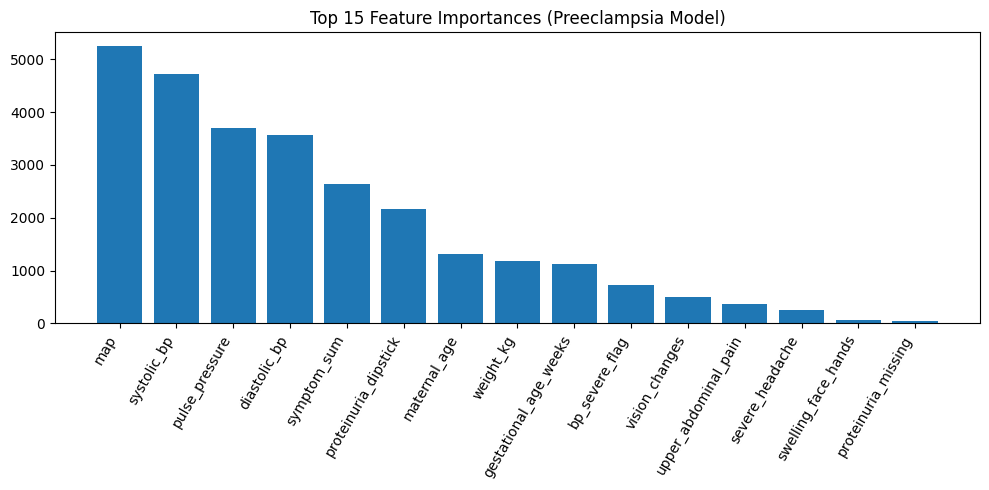

In [32]:
import matplotlib.pyplot as plt

imp = pd.DataFrame({
    "feature": X_cols,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

display(imp.head(15))

plt.figure(figsize=(10, 5))
plt.bar(imp["feature"].head(15), imp["importance"].head(15))
plt.xticks(rotation=60, ha="right")
plt.title("Top 15 Feature Importances (Preeclampsia Model)")
plt.tight_layout()
plt.show()


## 11) Save Model Artifacts for Deployment + Retraining

We save:
✅ LightGBM model  
✅ feature list  
✅ meal category encoder  
✅ evaluation metrics  
✅ metadata for versioning  


In [33]:
MODEL_DIR = "models/preeclampsia_v1"
os.makedirs(MODEL_DIR, exist_ok=True)

# Save model
joblib.dump(model, os.path.join(MODEL_DIR, "preeclampsia_lgbm_model.pkl"))

# Save feature columns
with open(os.path.join(MODEL_DIR, "feature_columns.json"), "w") as f:
    json.dump(X_cols, f, indent=4)

# Save meal encoder
joblib.dump(le_meal, os.path.join(MODEL_DIR, "meal_category_encoder.pkl"))

# Save metrics
metrics = {
    "r2": float(r2),
    "mae": float(mae),
    "rmse": float(rmse)
}
with open(os.path.join(MODEL_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=4)

# Save training metadata
metadata = {
    "model_name": "preeclampsia_risk_score_lgbm",
    "version": "v1",
    "target": TARGET,
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "feature_count": int(len(X_cols)),
    "tier_thresholds": {"low_max": 0.399, "medium_max": 0.699, "high_min": 0.700},
    "notes": "Patient-wise split + engineered clinical features + early stopping to reduce overfitting."
}

with open(os.path.join(MODEL_DIR, "metadata.json"), "w") as f:
    json.dump(metadata, f, indent=4)

print("✅ Saved model + artifacts into:", MODEL_DIR)


✅ Saved model + artifacts into: models/preeclampsia_v1


# ✅ Notebook Completed

### Outputs Saved
✅ `models/preeclampsia_v1/preeclampsia_lgbm_model.pkl`  
✅ `models/preeclampsia_v1/feature_columns.json`  
✅ `models/preeclampsia_v1/meal_category_encoder.pkl`  
✅ `models/preeclampsia_v1/metrics.json`  
✅ `models/preeclampsia_v1/metadata.json`

---

### Next Notebook
➡️ **02_train_macrosomia_lgbm.ipynb**  
(Train macrosomia risk score regression model)
